# Predicting the Severity of Geomagnetic Disturbances Caused by Earth-impacting Coronal Mass Ejections Using Explainable Physics-aware Machine Learning

**Hongyang Zhang**

## Testing workflow
Run all cells from top to bottom using the local Python environment with the dependencies in `requirements.txt` already installed.
All model and testing code is included below. The only external input files are the local trained model and test data.
The original Python source is preserved in the model and test definition cells.

## 1. Local files and imports
Open the notebook from the repository folder. The input and output locations below are relative paths; no fixed repository folder name or personal absolute path is required.

In [1]:
# =========================================================================
#   (c) Copyright 2026
#   All rights reserved
#   Programs written by Hongyang Zhang
#   Department of Computer Science
#   New Jersey Institute of Technology
#   University Heights, Newark, NJ 07102, USA
#
#   Permission to use, copy, modify, and distribute this
#   software and its documentation for any purpose and without
#   fee is hereby granted, provided that this copyright
#   notice appears in all copies. Programmer(s) makes no
#   representations about the suitability of this
#   software for any purpose.  It is provided "as is" without
#   express or implied warranty.
# =========================================================================

from pathlib import Path

MODEL_DIR = "./pre-trained model and weights"
TEST_CSV_PATH = "./testing data/test.csv"
OUTPUT_DIR = "./results"

MODEL_DIR = Path(MODEL_DIR)
TEST_CSV_PATH = Path(TEST_CSV_PATH)
OUTPUT_DIR = Path(OUTPUT_DIR)

for input_file in (MODEL_DIR / "model.pkl", TEST_CSV_PATH):
    if not input_file.is_file():
        raise FileNotFoundError(
            f"Missing local input: {input_file}. Run this notebook from the repository folder."
        )


In [2]:
"""Load the fitted forest and convert residual predictions to Max Kp."""
import pickle
import warnings
from pathlib import Path

import numpy as np
from quantile_forest import RandomForestQuantileRegressor
from sklearn.exceptions import InconsistentVersionWarning




## 2. Model loading and prediction
These functions load the supplied model bundle and convert its residual predictions into Max Kp predictions and intervals.

In [3]:
def load_model(directory):
    directory = Path(directory)
    # The bundle uses a plain dictionary and a native forest, with no project classes.
    with warnings.catch_warnings():
        warnings.simplefilter("error", InconsistentVersionWarning)
        with (directory / "model.pkl").open("rb") as stream:
            bundle = pickle.load(stream)
    if not isinstance(bundle, dict) or bundle.get("format_version") != 1:
        raise ValueError("Unsupported model bundle format.")
    forest, metadata = bundle["forest"], bundle["metadata"]
    features = metadata["features"]
    if not isinstance(forest, RandomForestQuantileRegressor):
        raise ValueError("The model must be a fitted RandomForestQuantileRegressor.")
    if len(features) != forest.n_features_in_ or len(set(features)) != len(features):
        raise ValueError("The feature list does not match the fitted forest.")
    if metadata["method"] != "zero_residual" or metadata["kp_bounds"] != [0, 9]:
        raise ValueError("This program requires the residual Kp model with bounds [0, 9].")
    lo, hi = map(float, bundle["quantiles"])
    if not 0 < lo < 0.5 < hi < 1:
        raise ValueError("Interval quantiles must satisfy 0 < lower < 0.5 < upper < 1.")
    return forest, metadata, (lo, hi)




In [4]:
def predict(forest, metadata, quantiles, frame):
    """Return lower, median and upper Kp; observations are not model inputs."""
    features = metadata["features"]
    baseline = metadata["baseline_col"]
    required = features + [baseline]
    if frame.empty or frame.columns.duplicated().any():
        raise ValueError("Provide nonempty data with unique column names.")
    missing = [name for name in required if name not in frame]
    if missing:
        raise ValueError(f"Missing input columns: {missing}")
    if not np.isfinite(frame[required].to_numpy(dtype=float)).all():
        raise ValueError("All model inputs must be finite numeric values.")
    residuals = forest.predict(frame[features].to_numpy(),
                               quantiles=[quantiles[0], 0.5, quantiles[1]])
    # Add the Scoreboard baseline to every quantile, then apply Kp bounds.
    result = np.clip(residuals + frame[baseline].to_numpy()[:, None], 0, 9)
    if not np.isfinite(result).all() or (np.diff(result, axis=1) < 0).any():
        raise ValueError("The model returned invalid or unordered predictions.")
    return result


## 3. Test definitions
The adapter below makes the same model functions available to the test code inside Jupyter; no external Python file is read or written. The test entry point is run in Step 4.


In [5]:
import sys
from types import ModuleType

_missing = object()
_runtime = {
    "module": sys.modules.get("model", _missing),
    "path": sys.path[:],
    "argv": sys.argv,
    "bytecode": sys.dont_write_bytecode,
    "globals": {key: globals().get(key, _missing)
                for key in ("__file__", "__name__", "__doc__")},
}

def _restore_notebook_runtime():
    sys.path[:] = _runtime["path"]
    sys.argv = _runtime["argv"]
    sys.dont_write_bytecode = _runtime["bytecode"]
    if _runtime["module"] is _missing:
        sys.modules.pop("model", None)
    else:
        sys.modules["model"] = _runtime["module"]
    for key, value in _runtime["globals"].items():
        if value is _missing:
            globals().pop(key, None)
        else:
            globals()[key] = value

_model_module = ModuleType("model")
_model_module.load_model = load_model
_model_module.predict = predict
sys.modules["model"] = _model_module
__file__ = str(Path.cwd() / "testing code" / "test.py")
__name__ = "_kpforest_notebook_definitions"
__doc__ = "Evaluate the supplied model and print the 24-event paper example."


In [6]:
"""Evaluate the supplied model and print the 24-event paper example."""
import argparse
import json
import sys
from pathlib import Path

ROOT = Path(__file__).resolve().parents[1]
sys.dont_write_bytecode = True
sys.path.insert(0, str(ROOT / "model code"))

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

from model import load_model, predict





In [7]:
def evaluate(observed, prediction):
    """MAE/MRE use the median; EC includes both interval endpoints."""
    y = np.asarray(observed, dtype=float)
    if y.ndim != 1 or len(y) != len(prediction) or not np.isfinite(y).all():
        raise ValueError("Each prediction requires a finite observed Max Kp.")
    if len(y) < 2 or not np.any(y != 0):
        raise ValueError("Scoring requires at least two events and a nonzero target.")
    nonzero = y != 0
    lower, point, upper = prediction.T
    return {
        "MAE": float(mean_absolute_error(y, point)),
        "MRE": float(np.mean(np.abs(point[nonzero] - y[nonzero]) / np.abs(y[nonzero]))),
        "R2": float(r2_score(y, point)),
        "EC": float(np.mean((y >= lower) & (y <= upper)) * 100),
    }




In [8]:
def main(argv=None):
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--model", type=Path, default=ROOT / "pre-trained model and weights")
    parser.add_argument("--data", type=Path, default=ROOT / "testing data/test.csv")
    parser.add_argument("--output", type=Path, default=ROOT / "results")
    args = parser.parse_args(argv)
    forest, metadata, quantiles = load_model(args.model)
    frame = pd.read_csv(args.data)
    values = predict(forest, metadata, quantiles, frame)
    observed = frame[metadata["target_col"]].to_numpy(dtype=float)
    metrics = evaluate(observed, values)
    times = pd.to_datetime(frame["observedTime"], utc=True, errors="raise")
    if times.isna().any():
        raise ValueError("Each test event requires an onset time.")
    predictions = pd.DataFrame({
        "event_onset_time": times.dt.strftime("%Y-%m-%dT%H:%M:%SZ"),
        "predicted_max_kp": values[:, 1],
        "predicted_max_kp_lower": values[:, 0],
        "predicted_max_kp_upper": values[:, 2],
        "observed_max_kp": observed,
    })
    args.output.mkdir(parents=True, exist_ok=True)
    predictions.to_csv(args.output / "predictions.csv", index=False)
    (args.output / "metrics.json").write_text(
        json.dumps(metrics, indent=2, allow_nan=False) + "\n", encoding="utf-8")
    for row in predictions.itertuples(index=False):
        print(f"Event onset time: {row.event_onset_time}  "
              f"Predicted Max Kp: {row.predicted_max_kp:.4f}  "
              f"Predicted Max Kp range: {row.predicted_max_kp_lower:.4f} to "
              f"{row.predicted_max_kp_upper:.4f}  "
              f"Observed Max Kp: {row.observed_max_kp:.2f}")
    print(f"\nMAE: {metrics['MAE']:.4f}")
    print(f"MRE: {metrics['MRE']:.4f}")
    print(f"R^2: {metrics['R2']:.4f}")
    print(f"EC: {metrics['EC']:.2f}%")
    return predictions


## 4. Run the test
Each output line reports an event's UTC onset time, predicted Max Kp, prediction interval, and observed Max Kp. The last four lines report MAE, MRE, R², and EC.
The original test function uses its existing command-line options to receive the relative paths configured in Step 1.

In [9]:
try:
    sys.argv = [
        "workflow.ipynb",
        "--model", str(MODEL_DIR),
        "--data", str(TEST_CSV_PATH),
        "--output", str(OUTPUT_DIR),
    ]
    _ = main()
finally:
    _restore_notebook_runtime()


Event onset time: 2013-03-15T06:54:00Z  Predicted Max Kp: 6.0952  Predicted Max Kp range: 3.7500 to 7.0500  Observed Max Kp: 6.33
Event onset time: 2014-02-12T05:48:00Z  Predicted Max Kp: 5.5867  Predicted Max Kp range: 3.8333 to 6.3417  Observed Max Kp: 5.00
Event onset time: 2014-04-18T13:09:00Z  Predicted Max Kp: 5.5750  Predicted Max Kp range: 3.6250 to 6.4730  Observed Max Kp: 5.00
Event onset time: 2017-07-14T01:36:00Z  Predicted Max Kp: 4.9429  Predicted Max Kp range: 3.8232 to 5.7286  Observed Max Kp: 6.00
Event onset time: 2017-09-04T20:36:00Z  Predicted Max Kp: 6.5208  Predicted Max Kp range: 4.8125 to 7.3661  Observed Max Kp: 4.00
Event onset time: 2017-09-06T12:24:00Z  Predicted Max Kp: 6.0595  Predicted Max Kp range: 4.4167 to 6.9079  Observed Max Kp: 8.00
Event onset time: 2021-02-20T11:00:00Z  Predicted Max Kp: 5.3333  Predicted Max Kp range: 3.5000 to 6.2619  Observed Max Kp: 4.00
Event onset time: 2021-08-24T13:25:00Z  Predicted Max Kp: 5.3333  Predicted Max Kp range: 

Full-precision results are saved as `results/predictions.csv` and `results/metrics.json`.
The supplied `prediction.pdf` is a printout of this executed notebook, including its code and actual results.
To update it, run all cells, save the notebook, and print it to PDF from Jupyter. Running the numerical test does not overwrite the PDF.

## 5. Figure 3
The figure below is generated from the predictions calculated in Step 4. Orange circles show observed Max Kp, blue diamonds show predicted Max Kp, and grey bars show prediction intervals for the 24 test events. The figure uses the paper's layout and is saved as `figure3.png` in the repository folder.

In [10]:
"""Draw Figure 3 from the predictions computed by the test workflow."""
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.transforms import Bbox
import numpy as np
import pandas as pd




In [11]:
def plot_figure3(predictions, destination):
    """Save the paper-style figure without changing any prediction values."""
    frame = predictions.copy()
    frame["date"] = pd.to_datetime(frame.event_onset_time, utc=True, errors="raise")
    frame = frame.sort_values("date", kind="stable").reset_index(drop=True)
    observed, point, lower, upper = (frame[column].to_numpy() for column in (
        "observed_max_kp", "predicted_max_kp",
        "predicted_max_kp_lower", "predicted_max_kp_upper"))
    if frame.empty or not np.isfinite([observed, point, lower, upper]).all():
        raise ValueError("Figure 3 requires finite predictions and observations.")
    if not ((lower <= point) & (point <= upper)).all():
        raise ValueError("Each prediction must lie within its interval.")
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    style = {
        "font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans"],
        "font.size": 17, "axes.labelsize": 17,
        "xtick.labelsize": 17, "ytick.labelsize": 17,
        "axes.grid": False, "figure.dpi": 300, "savefig.dpi": 300,
        "figure.facecolor": "white", "axes.facecolor": "white",
        "mathtext.fontset": "dejavusans",
    }
    with plt.rc_context(style):
        x = np.arange(len(frame))
        fig, ax = plt.subplots(figsize=(14, 10))
        ax.errorbar(x, point, yerr=[point - lower, upper - point], fmt="none",
                    ecolor="#AAAAAA", elinewidth=3.5, capsize=8,
                    capthick=3.5, alpha=.85, zorder=10)
        ax.scatter(x, point, marker="D", s=120, color="#0055AA",
                   edgecolors="white", linewidth=1.5, zorder=20)
        ax.scatter(x, observed, marker="o", s=180, facecolors="none",
                   edgecolors="#FF8800", linewidth=2.5, zorder=22)
        ax.set_xticks(x, frame.date.dt.strftime("%Y-%m-%d"), rotation=90, ha="center")
        ax.set_yticks(np.arange(10))
        ax.set_ylim(-.5, 9.5)
        ax.set_xlabel("CME Onset Time", fontsize=24, labelpad=20)
        ax.set_ylabel("Max Kp", fontsize=24, labelpad=20)
        ax.grid(True, linestyle=":", alpha=.4, axis="y")
        ax.spines[["right", "top"]].set_visible(False)
        handles = [
            Line2D([], [], marker="o", markerfacecolor="none", markeredgecolor="#FF8800",
                   markeredgewidth=2.5, markersize=12, linewidth=0, label="Observed Value"),
            Line2D([], [], marker="D", markerfacecolor="#0055AA", markeredgecolor="white",
                   markeredgewidth=1.5, markersize=10, linewidth=0, label="Predicted Value"),
            Line2D([], [], marker="|", color="#AAAAAA", markersize=12, linewidth=2,
                   label="Prediction Interval"),
        ]
        ax.legend(handles=handles, loc="lower left", framealpha=.9, edgecolor="none",
                  prop={"family": ["Arial", "DejaVu Sans"], "size": 17})
        fig.tight_layout()
        fig.canvas.draw()
        tight = fig.get_tightbbox(fig.canvas.get_renderer())
        width, height = (pixels / 300 + 1e-9 for pixels in (4107, 2907))
        if tight.width > width or tight.height > height:
            plt.close(fig)
            raise ValueError("The Figure 3 canvas would clip the plotted content.")
        box = Bbox.from_bounds(tight.x0 - (width - tight.width) / 2,
                               tight.y0 - (height - tight.height) / 2,
                               width, height)
        fig.savefig(destination, dpi=300, bbox_inches=box, pad_inches=0)
        plt.close(fig)
    return destination


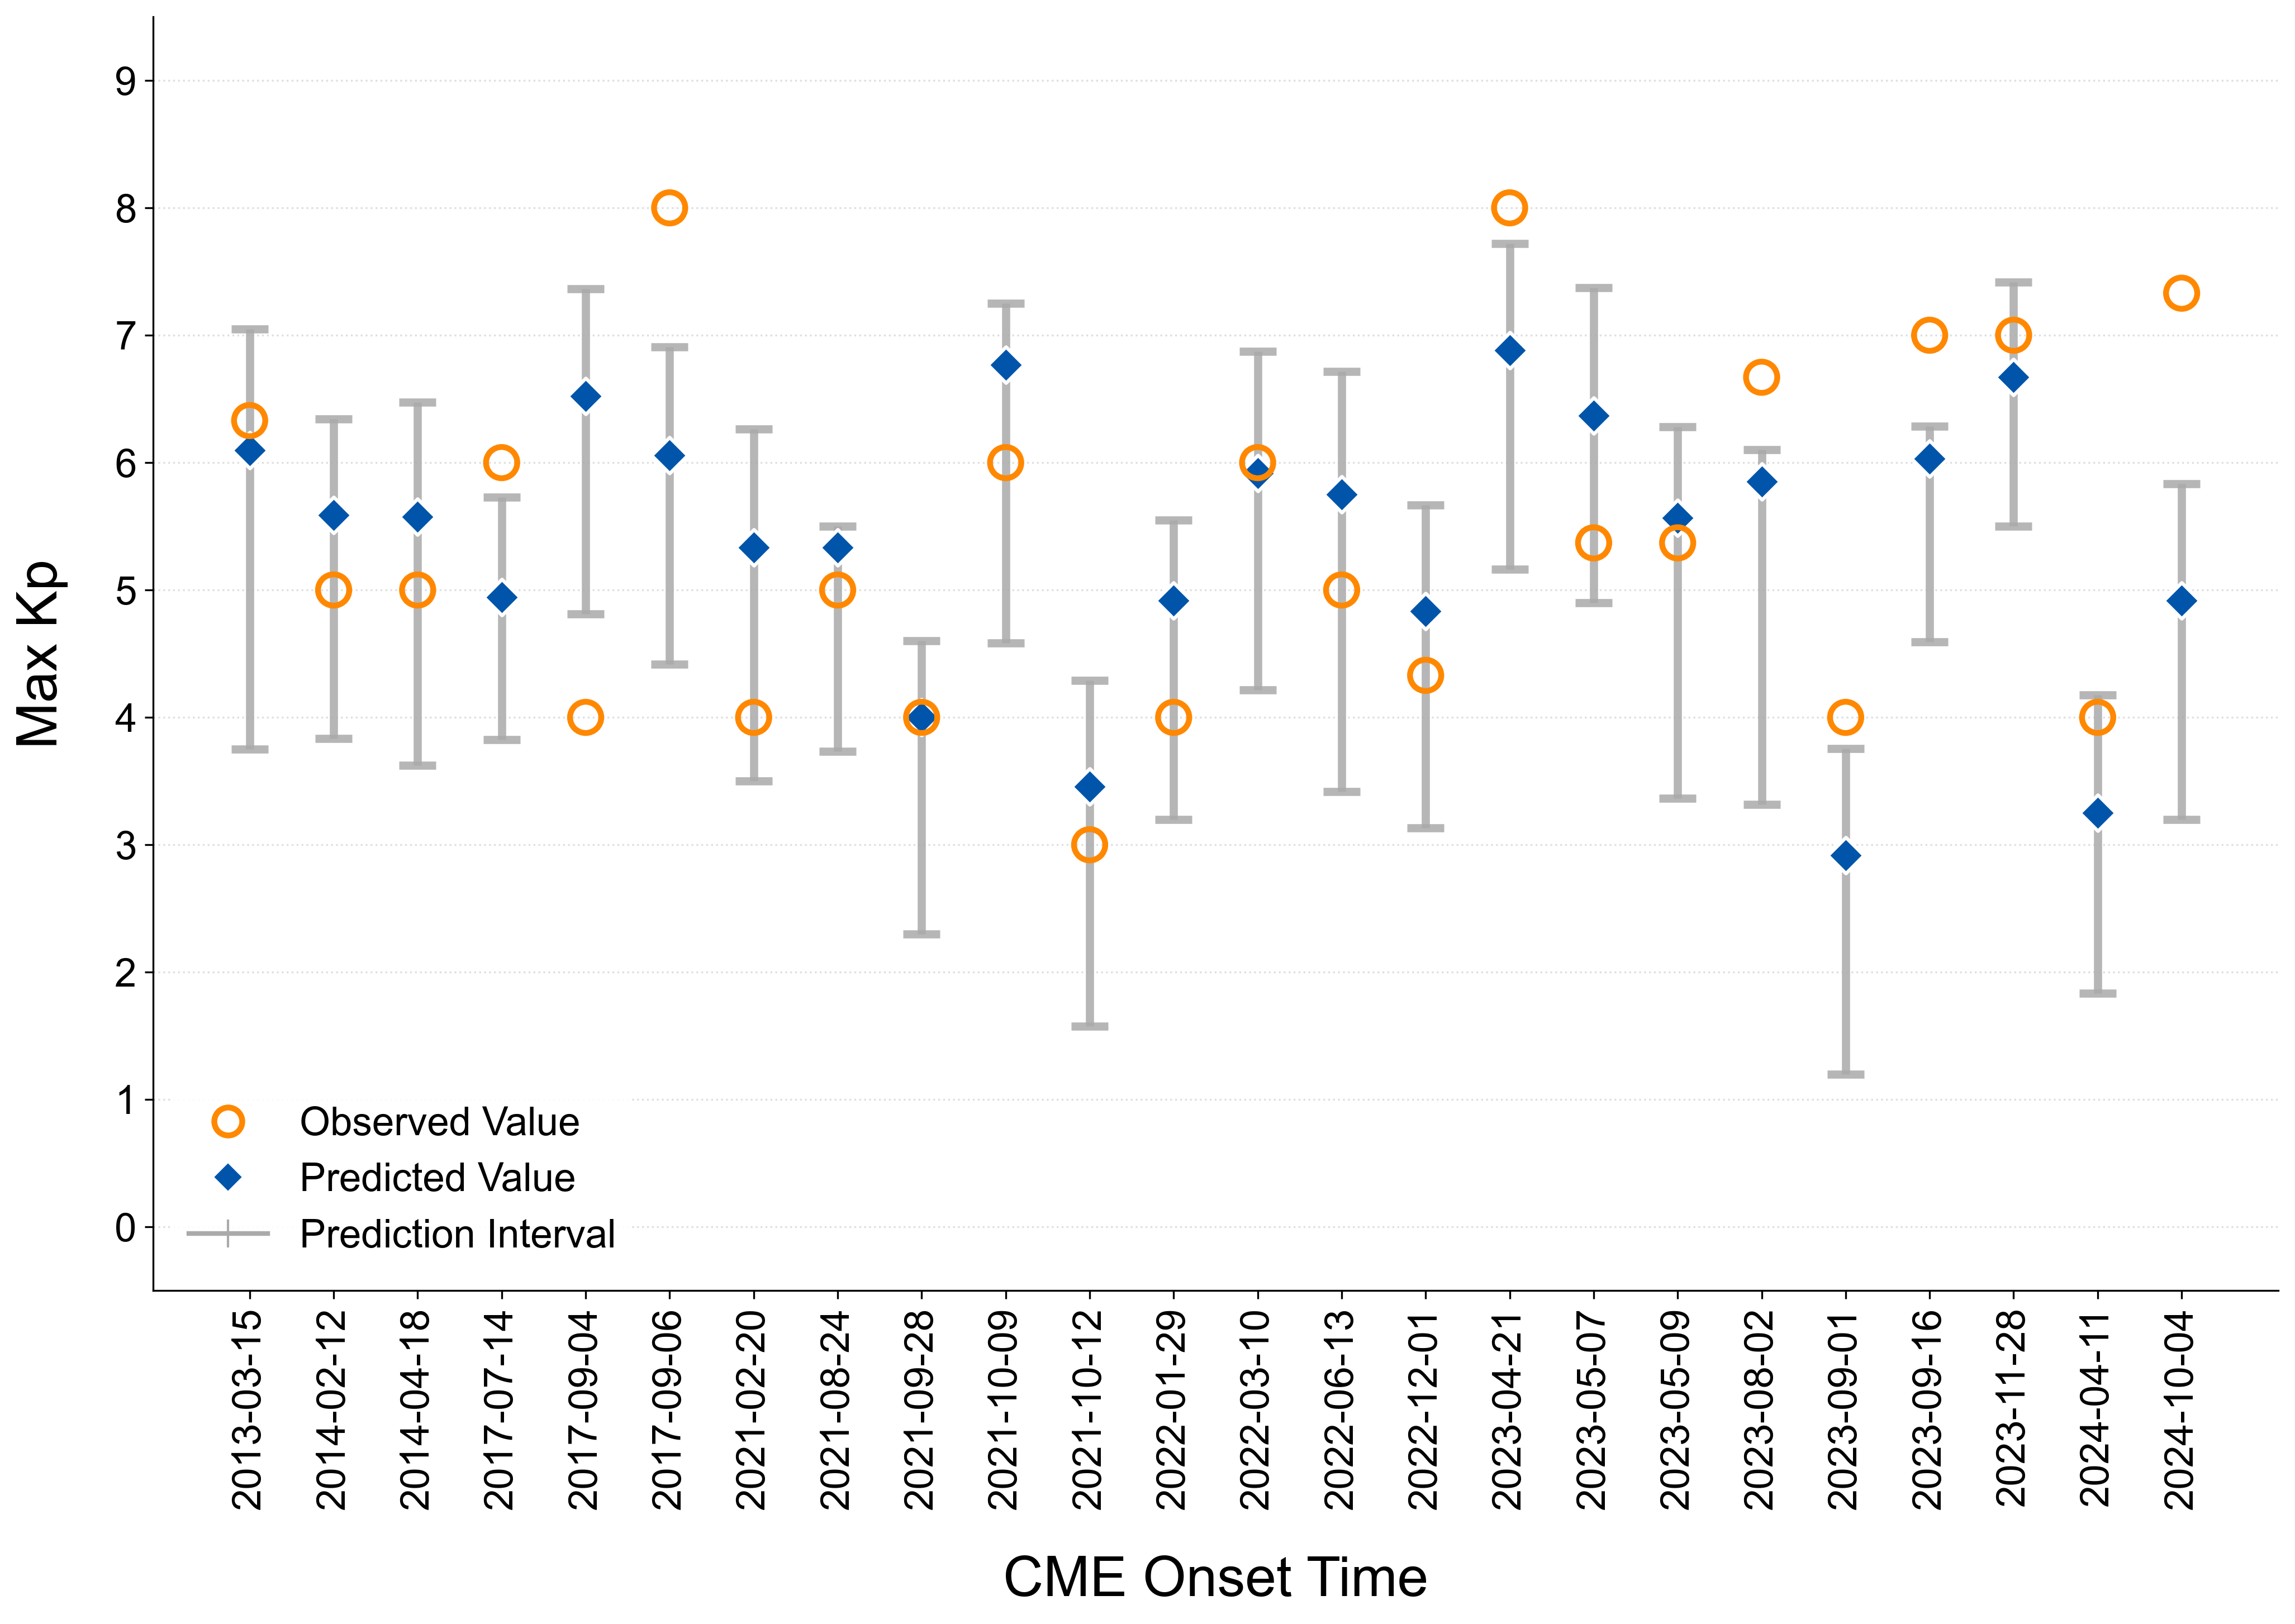

In [12]:
from IPython.display import Image, display

figure3_predictions = pd.read_csv(OUTPUT_DIR / "predictions.csv")
figure3_path = plot_figure3(figure3_predictions, "figure3.png")
display(Image(filename=str(figure3_path)))


**Figure 3.** Observed and predicted Max Kp values and prediction intervals for the 24 test CME events. The training and validation data in `trainingdata/` are supplied for reference and are not used during this test-only workflow.